In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import finufft

In [21]:
# ---== Global Variables ==--- #
num_threads = 1

In [22]:
# ---== wave vector generation ==--- #

# We always assume the domain is [0, 1]^2

def generate_k_vectors(num_per_dim = 52):
    """
    Generate wavevectors
    on a uniform 2D grid using fftfreq
    x:=num_per_dim ~ such that (x*x/2)/(4*N) = 4/10 <=> x = 4 * sqrt(2N/10)
    """

    min_threshhold = np.pi

    kx = np.fft.fftfreq(num_per_dim, d=1.0/num_per_dim) * 2 * np.pi
    ky = np.fft.fftfreq(num_per_dim, d=1.0/num_per_dim) * 2 * np.pi
    kx, ky = np.meshgrid(kx[kx >= 0.0], ky, indexing='ij')
    k_flat = np.stack((kx.ravel(), ky.ravel()), axis=0)
    
    # Apply cutoff
    max_k = np.max(np.abs(k_flat), axis=0)
    mask = (max_k > min_threshhold)
    return k_flat[:, mask]  # shape: (2, nk)


In [23]:
# ---== inital point pattern generation ==--- #

# Important: the domain is always [0, 1]^2

def random_point_pattern(N):
    return np.random.uniform(0, 1, size=(N, 2)) # shape : (rN, 2)

# ------
# the following methods generate approximately N points and exactly N points if N = k^2, for some k

def uniform_point_pattern(N):
    rN = round(np.sqrt(N))
    space = np.linspace(0.01, .99, rN)
    return np.array(np.meshgrid(space, space)).reshape(2, -1).T # shape : (rN, 2)

def perturbed_point_pattern(N, eps=0.01):
    uniform = uniform_point_pattern(N)
    rN = uniform.shape[0]
    pert_x = eps*np.random.uniform(-1, 1, size=(rN,))
    pert_y = eps*np.random.uniform(-1, 1, size=(rN,))
    uniform[:, 0] += pert_x
    uniform[:, 1] += pert_y
    return uniform  # shape : (rN, 2)

In [24]:
# weight function for different k vectors to ensure constraints equally 
# strong on all spherical shells for radially symmetric structure factors
def weight(k):
    k_magnitude = np.linalg.norm(k, axis=0)  # (M,)
    return 1./k_magnitude

def compute_rho(k, r):
    N = r.shape[0]
    rx = np.ascontiguousarray(r[:, 0])
    ry = np.ascontiguousarray(r[:, 1])
    c = np.ones(N, dtype=np.complex128)
    return finufft.nufft2d3(rx, ry, c, k[0, :], k[1, :], eps=1e-12, isign=+1, nthreads=num_threads) # (M,)

# for optimization purposes
def compute_S_rho(rho, N):
    return np.abs(rho)**2 / N

def compute_S(k, r):
    N = r.shape[0]
    return compute_S_rho(compute_rho(k, r), N)

def compute_bump(x, K_cutoff):
    A = 0.5                   # Height of the hill
    x0 = 0.95                 # Center of the hill before cutoff
    sigma = 0.05              # Width of the hill
    bump = 1 + A * np.exp(-((x - x0)**2) / (2 * sigma**2))
    #bump = np.where(x < K_cutoff, bump, 0.0)
    return bump

def compute_S0(k, D, H, alpha, K_cutoff):
    k_magnitude = np.linalg.norm(k, axis=0)  # (M,)
    S0 = np.where(k_magnitude < K_cutoff, D * (1 - H) * (k_magnitude**alpha) + H, 1.0)
    return S0 * compute_bump(k_magnitude/K_cutoff, K_cutoff)

def objective_function(x, k, S0_k):
    N = x.shape[0] // 2
    r = x.reshape(N, 2)
    r = np.mod(r, 1.0)
    S_kr = compute_S(k, r)
    return np.sum(weight(k) * (S_kr - S0_k)**2)

def gradient_function(x, k, S0_k):
    N = x.shape[0] // 2
    r = x.reshape(N, 2)
    r = np.mod(r, 1.0)
    grad = np.zeros_like(r) # (N, 2)
    rho = compute_rho(k, r) # (M,)
    S_kr = compute_S_rho(rho, N) # (M,)
    factor = -4.j/N * weight(k) * ((S_kr - S0_k) * rho)
    C_hat_x = k[0, :] * factor # (M, )
    C_hat_y = k[1, :] * factor # (M, )
    rx = np.ascontiguousarray(r[:, 0])
    ry = np.ascontiguousarray(r[:, 1])
    grad[:, 0] = np.real(finufft.nufft2d3(k[0, :], k[1, :], C_hat_x, rx, ry, isign=-1, nthreads=num_threads))
    grad[:, 1] = np.real(finufft.nufft2d3(k[0, :], k[1, :], C_hat_y, rx, ry, isign=-1, nthreads=num_threads))
    return grad.flatten()

In [25]:
# ---== Visualization ==--- #

def plot_wave_vectors(k):
    plt.figure(figsize=(6, 6))
    plt.scatter(k[0, :], k[1, :], marker="x", color="green")
    plt.xlabel("$k_x$")
    plt.ylabel("$k_y$")
    plt.title("Wave vectors")
    plt.show()

def plot_particles(r, title):
    plt.figure(figsize=(6, 6))
    r = np.mod(r, 1.0) 
    plt.scatter(r[:, 0], r[:, 1], c="blue", s=20)
    plt.title(title)
    plt.gca().set_aspect('equal')
    plt.show()

def plot_structure_factor(r, k, K_cutoff, S0_k, title):
    S_kr = compute_S(k, r)
    print(S_kr.shape)
    k_magnitude = np.linalg.norm(k, axis=0)
    plt.figure(figsize=(8, 5))
    plt.scatter(k_magnitude/K_cutoff, S_kr, color="red", label="Computed S(k)")
    plt.scatter(k_magnitude/K_cutoff, S0_k, color="green", label="Computed S_0(k)", marker="x")
    plt.xlabel("|k|/K")
    plt.ylabel("S(k)")
    plt.title(title)
    plt.legend()
    plt.show()

In [26]:
for i in range(10):

    np.random.seed(i)  # For reproducibility

    # ---== Parameters ==--- #

    N = 1024

    # Target structure factor parameters
    H = 1e-4
    alpha = 100.
    K_cutoff = 44*np.pi
    D = np.pow(K_cutoff, -alpha)

    r_init = perturbed_point_pattern(N)
    # since some point pattern generation algos dont give exactly N
    N = r_init.shape[0] 

    k = np.ascontiguousarray(generate_k_vectors(int(4 * np.sqrt(2*N/10))))
    M = k.shape[1]

    # Plot wave vectors used:
    # plot_wave_vectors(k)

    # target structure factor precomputation
    S0_k = compute_S0(k, D, H, alpha, K_cutoff)

    # Plot before optimization
    # plot_particles(r_init, "Initial Particle Configuration")
    # plot_structure_factor(r_init, k, K_cutoff, S0_k, "Initial Structure Factor")

    # print("Value before optimizing: ", objective_function(r_init.flatten(), k, S0_k))

    # ---== Run Optimization ==--- #
    res = minimize(
        fun=objective_function,
        x0=r_init.flatten(),
        jac=gradient_function,
        args=(k, S0_k),
        method="BFGS",
        options={"disp": True, "maxiter": 1000},
        tol=1e-8
    )

    # ---== Postprocess ==--- #

    r_opt = res.x.reshape(N, 2)  # Final particle positions
    print(res)

    # Save point pattern:
    outfile = f"point_patterns/bump_vs_no_bump/{i}b_pp.npy"
    np.save(outfile, r_opt)
    with open("point_patterns/bump_vs_no_bump/{i}b_parms.csv", 'w') as f:
            f.write("N, M, D, H, K_cutoff, alpha\n")
            f.write(f"{N},{M},{D},{H},{K_cutoff},{alpha}\n")
    print("parameters saved to parms.csv")
    print(f"phi saved to {outfile}")

    # Plot after optimization
    # plot_particles(r_opt, "Optimized Particle Configuration")
    # plot_structure_factor(r_opt, k, K_cutoff, S0_k, "Optimized Structure Factor")


c:\Users\eioer\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_minimize.py:733: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 0.000252
         Iterations: 1000
         Function evaluations: 1006
         Gradient evaluations: 1006
  message: Maximum number of iterations has been exceeded.
  success: False
   status: 1
      fun: 0.0002516063184566914
        x: [ 1.897e-02  5.127e-02 ...  9.952e-01  1.005e+00]
      nit: 1000
      jac: [-1.857e-03  6.202e-05 ...  2.567e-04  4.606e-04]
 hess_inv: [[ 5.224e-01 -8.656e-03 ...  3.184e-02  8.799e-04]
            [-8.656e-03  5.384e-01 ... -2.807e-02 -3.407e-02]
            ...
            [ 3.184e-02 -2.807e-02 ...  5.370e-01 -4.410e-03]
            [ 8.799e-04 -3.407e-02 ... -4.410e-03  5.252e-01]]
     nfev: 1006
     njev: 1006
parameters saved to parms.csv
phi saved to point_patterns/bump_vs_no_bump/0b_pp.npy


c:\Users\eioer\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_minimize.py:733: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 0.000260
         Iterations: 1000
         Function evaluations: 1003
         Gradient evaluations: 1003
  message: Maximum number of iterations has been exceeded.
  success: False
   status: 1
      fun: 0.0002598810771816343
        x: [ 1.790e-02  3.696e-02 ...  9.892e-01  9.918e-01]
      nit: 1000
      jac: [-2.722e-04  7.849e-04 ...  3.851e-04 -2.549e-05]
 hess_inv: [[ 5.043e-01  3.347e-02 ... -3.845e-04  1.073e-03]
            [ 3.347e-02  5.658e-01 ...  3.013e-02  2.896e-02]
            ...
            [-3.845e-04  3.013e-02 ...  5.314e-01 -2.040e-02]
            [ 1.073e-03  2.896e-02 ... -2.040e-02  4.919e-01]]
     nfev: 1003
     njev: 1003
parameters saved to parms.csv
phi saved to point_patterns/bump_vs_no_bump/1b_pp.npy


c:\Users\eioer\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_minimize.py:733: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


...

c:\Users\eioer\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_minimize.py:733: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 0.000234
         Iterations: 1000
         Function evaluations: 1003
         Gradient evaluations: 1003
  message: Maximum number of iterations has been exceeded.
  success: False
   status: 1
      fun: 0.00023393472941780463
        x: [ 1.285e-02  2.481e-02 ...  9.973e-01  9.769e-01]
      nit: 1000
      jac: [-9.667e-04  1.120e-03 ...  3.125e-04 -7.776e-04]
 hess_inv: [[ 5.520e-01 -1.448e-02 ...  7.479e-03  1.771e-02]
            [-1.448e-02  5.171e-01 ...  5.689e-03 -3.637e-02]
            ...
            [ 7.479e-03  5.689e-03 ...  5.190e-01  8.689e-03]
            [ 1.771e-02 -3.637e-02 ...  8.689e-03  5.471e-01]]
     nfev: 1003
     njev: 1003
parameters saved to parms.csv
phi saved to point_patterns/bump_vs_no_bump/7b_pp.npy


c:\Users\eioer\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_minimize.py:733: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 0.000243
         Iterations: 1000
         Function evaluations: 1003
         Gradient evaluations: 1003
  message: Maximum number of iterations has been exceeded.
  success: False
   status: 1
      fun: 0.00024319603298654407
        x: [ 3.332e-02  1.044e-02 ...  1.004e+00  9.806e-01]
      nit: 1000
      jac: [-7.604e-05 -1.000e-03 ... -9.544e-04  3.542e-04]
 hess_inv: [[ 5.218e-01  8.079e-03 ... -3.450e-02 -2.306e-03]
            [ 8.079e-03  5.610e-01 ... -3.735e-03 -2.744e-02]
            ...
            [-3.450e-02 -3.735e-03 ...  5.418e-01  5.597e-04]
            [-2.306e-03 -2.744e-02 ...  5.597e-04  5.027e-01]]
     nfev: 1003
     njev: 1003
parameters saved to parms.csv
phi saved to point_patterns/bump_vs_no_bump/8b_pp.npy
         Current function value: 0.000358
         Iterations: 1000
         Function evaluations: 1003
         Gradient evaluations: 1003
  message: Maximum number of iterations has been exceeded.
  success: False
  

c:\Users\eioer\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_minimize.py:733: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


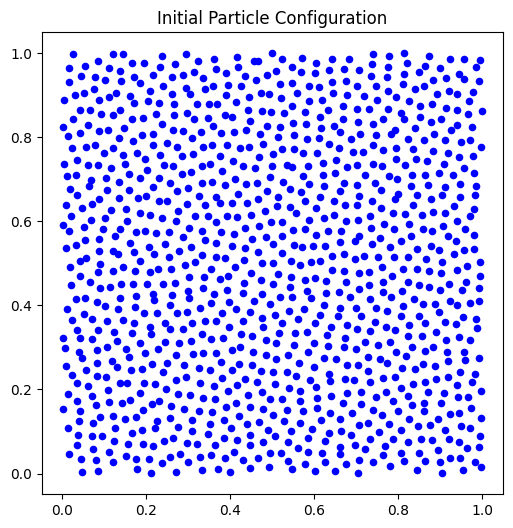

(1351,)


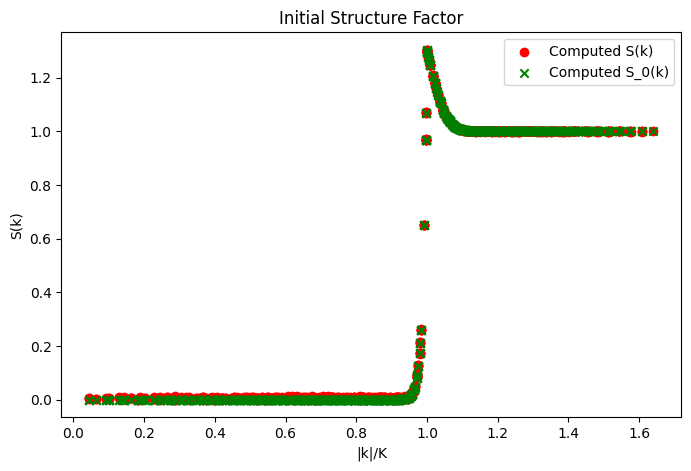

(non nuFFT) Value after optimizing:  0.00035754671282328595


In [27]:
# Some testing for correctness

def compute_S(k, r):
    N = r.shape[0] 
    k_dot_r = r @ k  # (N, M)
    sum_exp = np.sum(np.exp(1j * k_dot_r), axis=0)  # (M,)
    return np.abs(sum_exp)**2 / N

def plot_structure_factor(r, k, K_cutoff, S0_k, title):
    S_kr = compute_S(k, r)
    print(S_kr.shape)
    k_magnitude = np.linalg.norm(k, axis=0)
    plt.figure(figsize=(8, 5))
    plt.scatter(k_magnitude/K_cutoff, S_kr, color="red", label="Computed S(k)")
    plt.scatter(k_magnitude/K_cutoff, S0_k, color="green", label="Computed S_0(k)", marker="x")
    plt.xlabel("|k|/K")
    plt.ylabel("S(k)")
    plt.title(title)
    plt.legend()
    plt.show()

k = np.ascontiguousarray(generate_k_vectors())
M = k.shape[1]

# Plot wave vectors used:
S0_k = compute_S0(k, D, H, alpha, K_cutoff)

plot_particles(r_opt, "Initial Particle Configuration")
plot_structure_factor(r_opt, -k, K_cutoff, S0_k, "Initial Structure Factor") # the strucutre factor should be the same for -k (=> it is)

print("(non nuFFT) Value after optimizing: ", objective_function(r_opt.flatten(), k, S0_k)) # here we use the non nuFFT way to check if it is also small (=> it is)